# Week 4 — The Water-Wave Boundary Value Problem

**OE 754 / 854 — Ocean Waves & Tides**

By the end of this week, the water-wave problem is condensed to four equations:

$$\nabla^2 \phi = 0, \nabla\cdot(-\nabla\phi)=0, \qquad \left.\frac{\partial\phi}{\partial z}\right|_{z=-h} = 0,$$

$$\left.\frac{\partial\eta}{\partial t} + u\frac{\partial\eta}{\partial x} = w\right|_{z=\eta} \quad\text{(KFSBC)}, \qquad
\left.-\frac{\partial\phi}{\partial t} + \tfrac12|\mathbf u|^2 + g\eta = C(t)\right|_{z=\eta} \quad\text{(DFSBC)}.$$

The rest of the course builds on these. Next week we derive the Airy solution. This notebook tests numerically that it satisfies these equations in the linearized limit.

### Goals

1. Numerically verify $\nabla^2\phi = 0$ for a candidate Airy potential.
2. Check each boundary condition at three levels of approximation: linearized (they hold exactly), second-order (small error), and fully nonlinear (error grows with $ka$).
3. Draw the geometry of the problem: the wave domain, the boundaries, and what each boundary condition enforces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs

g = 9.81

## 1. The candidate Airy potential

Next week we'll derive

$$\phi(x,z,t) = \frac{gH}{2\omega}\frac{\cosh k(h+z)}{\cosh kh}\sin(\omega t - kx), \qquad \eta(x,t) = \frac{H}{2}\cos(kx - \omega t),$$

with $\omega^2 = gk\tanh kh$. For now, we write it down and check that it satisfies Laplace's equation and the bottom BC.

In [2]:
# Test wave: T = 10 s, h = 20 m (intermediate depth), H = 1 m
T, h, H = 10.0, 20.0, 1.0
omega = 2 * np.pi / T
# Newton solve for k from the dispersion relation
def solve_k(omega, h, tol=1e-12):
    k = omega**2 / g
    for _ in range(50):
        tkh = np.tanh(k*h)
        f = omega**2 - g*k*tkh
        fp = -g*tkh - g*h*k*(1-tkh**2)
        dk = f/fp
        k -= dk
        if abs(dk)<tol: break
    return k
k = solve_k(omega, h)
print(f'T={T}s, h={h}m, H={H}m')
print(f'k = {k:.5f} rad/m,  kh = {k*h:.3f},  L = {2*np.pi/k:.2f} m')


def phi(x, z, t):
    return g*H/(2*omega) * np.cosh(k*(h+z))/np.cosh(k*h) * np.sin(omega*t - k*x)

def eta(x, t):
    return H/2 * np.cos(k*x - omega*t)

def u_analytic(x, z, t):
    # u = -dphi/dx, D&D convention
    return g*H*k/(2*omega) * np.cosh(k*(h+z))/np.cosh(k*h) * np.cos(omega*t - k*x)

def w_analytic(x, z, t):
    return -g*H*k/(2*omega) * np.sinh(k*(h+z))/np.cosh(k*h) * np.sin(omega*t - k*x)


T=10.0s, h=20.0m, H=1.0m
k = 0.05183 rad/m,  kh = 1.037,  L = 121.24 m


## 2. Numerical check: $\nabla^2 \phi = 0$

Sample $\phi$ on a grid and compute $\partial^2\phi/\partial x^2 + \partial^2\phi/\partial z^2$ by central differences. If the candidate is harmonic, the result is zero to within the truncation error of the stencil.


In [3]:
# phi on a grid spanning one wavelength and the full depth
x = np.linspace(0, 2*np.pi/k, 201)
z = np.linspace(-h, 0, 81)
X, Z = np.meshgrid(x, z, indexing='xy')
t0 = 0.25*T
Phi = phi(X, Z, t0)

dx = x[1] - x[0]
dz = z[1] - z[0]

# Second derivatives by central differences, interior points
d2phi_dx2 = (Phi[:, 2:] - 2*Phi[:, 1:-1] + Phi[:, :-2]) / dx**2
d2phi_dz2 = (Phi[2:, :] - 2*Phi[1:-1, :] + Phi[:-2, :]) / dz**2
# Align to common interior
laplacian = d2phi_dx2[1:-1, :] + d2phi_dz2[:, 1:-1]

scale = np.max(np.abs(Phi))
rel_lap = np.max(np.abs(laplacian)) / scale
# Leading truncation term (dx^2/12) phi_xxxx = (k dx)^2 k^2/12 relative to |phi|
trunc_est = (k*dx)**2 * k**2 / 12
print(f'Max |∇²φ| on interior grid = {np.max(np.abs(laplacian)):.2e}')
print(f'Max |φ|                      = {scale:.2e}')
print(f'Ratio                        = {rel_lap:.2e}  (expect (k dx)²k²/12 ≈ {trunc_est:.1e})')


Max |∇²φ| on interior grid = 2.00e-06
Max |φ|                      = 7.81e+00
Ratio                        = 2.56e-07  (expect (k dx)²k²/12 ≈ 2.2e-07)


The Laplacian sits at the level of finite-difference truncation error. The leading term of the five-point stencil is $(dx^2/12)\,\phi_{xxxx}$. So relative to $|\phi|$ we expect $(k\,dx)^2 k^2/12 \sim 2\times10^{-7}$. The ratio above reports the same. The Airy $\phi$ is harmonic analytically, so the residual is numerical.

The bottom BC $\partial\phi/\partial z|_{z=-h} = 0$ holds by construction. It's why we picked $\cosh k(h+z)$ over a general exponential:

In [4]:
# BBC: dphi/dz at z = -h, where sinh(k(h+z)) vanishes identically
dphi_dz_bed = g*H/(2*omega) * k * np.sinh(0) / np.cosh(k*h) * np.sin(omega*t0 - k*x)
print(f'max |∂φ/∂z| at z = -h : {np.max(np.abs(dphi_dz_bed)):.2e} 1/s')

max |∂φ/∂z| at z = -h : 0.00e+00 1/s


## 3. Free-surface boundary conditions at three levels

The FSBCs are the ones that get linearized. Three levels to check:

1. **Full nonlinear**: $w = \eta_t + u\eta_x$ at $z = \eta$.
2. **Second-order**: evaluate at $z = \eta$ but drop the $u\eta_x$ product.
3. **Linearized** (what next week's derivation uses): evaluate at $z = 0$ *and* drop $u\eta_x$.

The residual at each level gives the order of the correction it needs.

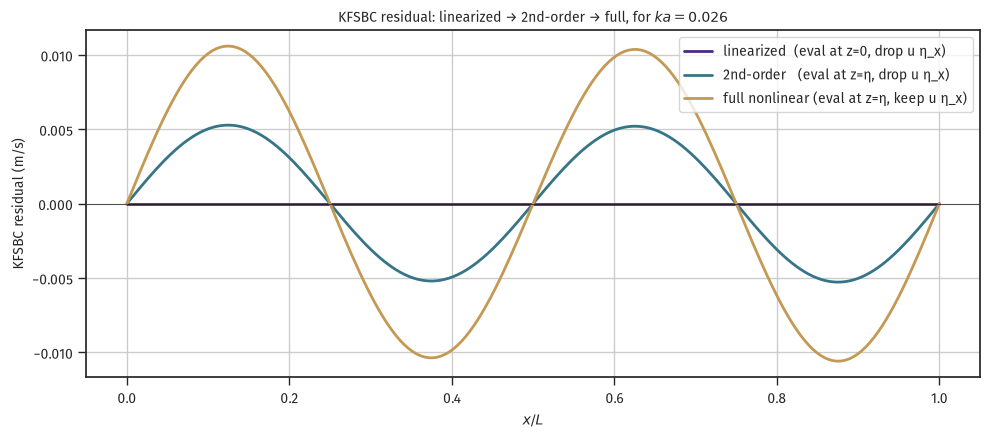

max |KFSBC residual|, m/s:
  linearized   : 0.000e+00
  2nd-order    : 5.279e-03   (Taylor-shift term)
  full         : 1.060e-02   (full / 2nd-order = 2.01)
linear balance |η_t| : 3.141e-01 m/s
full residual / linear balance = 3.4%


In [5]:
# KFSBC sampled along one wavelength at t = 0
x_samples = np.linspace(0, 2*np.pi/k, 200)
t = 0.0

eta_vals = eta(x_samples, t)
deta_dt = omega*H/2 * np.sin(k*x_samples - omega*t)   # d/dt of H/2 cos(kx - wt)
deta_dx = -k*H/2 * np.sin(k*x_samples - omega*t)      # d/dx

# Linearized: w at z = 0, drop u eta_x
w_at_zero  = w_analytic(x_samples, 0.0, t)
u_at_zero  = u_analytic(x_samples, 0.0, t)
res_lin = w_at_zero - deta_dt

# Second order: w at z = eta, drop u eta_x
w_at_eta = w_analytic(x_samples, eta_vals, t)
u_at_eta = u_analytic(x_samples, eta_vals, t)
res_2nd = w_at_eta - deta_dt

# Full nonlinear: w at z = eta, keep u eta_x
res_full = w_at_eta - deta_dt - u_at_eta*deta_dx

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(x_samples / (2*np.pi/k), res_lin,  lw=2, label='linearized  (eval at z=0, drop u η_x)', color=fs.color_list[0])
ax.plot(x_samples / (2*np.pi/k), res_2nd,  lw=2, label='2nd-order   (eval at z=η, drop u η_x)', color=fs.color_list[1])
ax.plot(x_samples / (2*np.pi/k), res_full, lw=2, label='full nonlinear (eval at z=η, keep u η_x)',
        color=fs.color_list[3])
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$x / L$')
ax.set_ylabel('KFSBC residual (m/s)')
ax.set_title(r'KFSBC residual: linearized → 2nd-order → full, for $ka = {:.3f}$'.format(k*H/2))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

lin_scale = np.max(np.abs(deta_dt))   # size of the linear balance itself
print('max |KFSBC residual|, m/s:')
print(f'  linearized   : {np.max(np.abs(res_lin)):.3e}')
print(f'  2nd-order    : {np.max(np.abs(res_2nd)):.3e}   (Taylor-shift term)')
print(f'  full         : {np.max(np.abs(res_full)):.3e}   (full / 2nd-order = {np.max(np.abs(res_full))/np.max(np.abs(res_2nd)):.2f})')
print(f'linear balance |η_t| : {lin_scale:.3e} m/s')
print(f'full residual / linear balance = {np.max(np.abs(res_full))/lin_scale:.1%}')


The linearized residual is zero to grid noise: the linearized Airy solution satisfies the linearized BC.

The second-order residual comes from evaluating at $z = \eta$ instead of $z = 0$. Consider the Taylor expansion $w(\eta) = w(0) + \eta\,w_z(0) + \cdots$. The leading correction is proportional to $\eta\,w_z$, which is $O(ka)$ relative to $w$.

The full residual adds the explicit $u\eta_x$ product. That term is also $O(ka)$ relative to $w$. Both are the same order. With the signs they carry, they add (no cancellation). So the full residual comes out about twice the second-order one. A second-order theory removes both (OE 795/895 material).

### $ka$ scaling

Sweep $H$ at fixed $T$ and $h$:

log–log slope: full = 2.008, 2nd-order = 2.006
full / 2nd-order ratio across the sweep: [2.00035445 2.0007092  2.00177527 2.00355812 2.00714648 2.01441321
 2.02930186]
  ka = 0.0013   full residual / linear balance = 0.17%
  ka = 0.0026   full residual / linear balance = 0.33%
  ka = 0.0065   full residual / linear balance = 0.84%
  ka = 0.0130   full residual / linear balance = 1.68%
  ka = 0.0259   full residual / linear balance = 3.37%
  ka = 0.0518   full residual / linear balance = 6.82%
  ka = 0.1037   full residual / linear balance = 13.94%


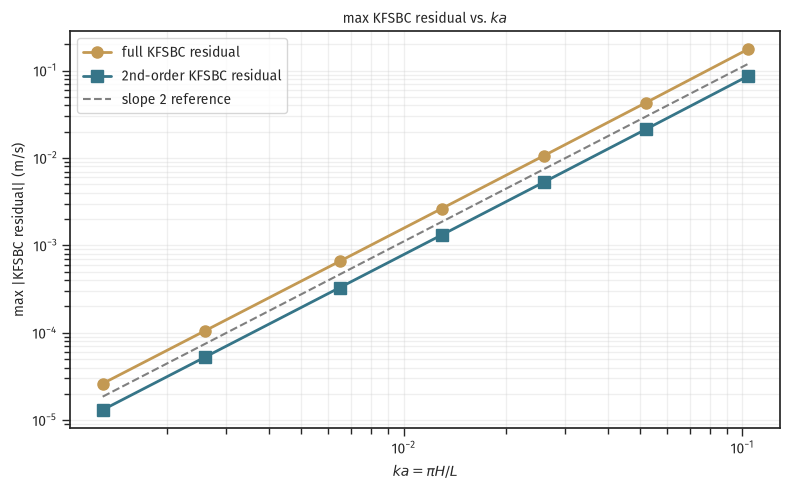

In [6]:
# Sweep H, tracking the max KFSBC residual
H_values = np.array([0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0])
max_res_full = []
max_res_2nd  = []

for H_sweep in H_values:
    def eta_local(x, t, H_=H_sweep):
        return H_/2 * np.cos(k*x - omega*t)
    def u_local(x, z, t, H_=H_sweep):
        return g*H_*k/(2*omega) * np.cosh(k*(h+z))/np.cosh(k*h) * np.cos(omega*t - k*x)
    def w_local(x, z, t, H_=H_sweep):
        return -g*H_*k/(2*omega) * np.sinh(k*(h+z))/np.cosh(k*h) * np.sin(omega*t - k*x)

    eta_vals = eta_local(x_samples, 0)
    detadt = omega*H_sweep/2 * np.sin(k*x_samples)
    detadx = -k*H_sweep/2 * np.sin(k*x_samples)
    res_full = w_local(x_samples, eta_vals, 0) - detadt - u_local(x_samples, eta_vals, 0)*detadx
    res_2nd  = w_local(x_samples, eta_vals, 0) - detadt
    max_res_full.append(np.max(np.abs(res_full)))
    max_res_2nd.append (np.max(np.abs(res_2nd)))

ka_values = k * H_values / 2
max_res_full = np.array(max_res_full)
max_res_2nd  = np.array(max_res_2nd)

# Log-log slopes of residual vs. ka
slope_full = np.polyfit(np.log(ka_values), np.log(max_res_full), 1)[0]
slope_2nd  = np.polyfit(np.log(ka_values), np.log(max_res_2nd),  1)[0]
print(f'log–log slope: full = {slope_full:.3f}, 2nd-order = {slope_2nd:.3f}')
print(f'full / 2nd-order ratio across the sweep: {max_res_full/max_res_2nd}')

# Residual relative to the linear balance |eta_t|, itself O(ka)
lin_scale_sweep = omega * H_values / 2
rel_to_linear = max_res_full / lin_scale_sweep
for kav, relv in zip(ka_values, rel_to_linear):
    print(f'  ka = {kav:.4f}   full residual / linear balance = {relv:.2%}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ka_values, max_res_full, 'o-', lw=2, ms=8, color=fs.color_list[3], label='full KFSBC residual')
ax.loglog(ka_values, max_res_2nd,  's-', lw=2, ms=8, color=fs.color_list[1], label='2nd-order KFSBC residual')
# Slope-2 reference, anchored between the two curves
ref_amp = np.sqrt(max_res_full[2]*max_res_2nd[2]) / ka_values[2]**2
ax.loglog(ka_values, ref_amp * ka_values**2, '--', color='0.5', label=r'slope 2 reference')
ax.set_xlabel(r'$ka = \pi H/L$')
ax.set_ylabel('max |KFSBC residual| (m/s)')
ax.set_title(r'max KFSBC residual vs. $ka$')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


Log–log slope of 2 for both residuals. So the absolute size of the neglected terms scales as $(ka)^2$. The scaling argument in the lecture predicts this. The two curves sit parallel, a factor of about 2 apart: the Taylor-shift term and the $u\eta_x$ term are the same order and add.

The linear balance itself is $O(ka)$. So relative to the terms we keep, the neglected ones are $O(ka)$. The percentages printed above track $ka$ closely. At the $ka = 0.026$ baseline the full residual is 3.4% of the linear balance. Typical swell at $ka \sim 0.04$ sits near 5%. This is small enough to drop for a first solution. It is also the size of the second-order correction that OE 795/895 puts back.

## 4. The BVP domain

The BVP domain is bounded below by the seabed and above by the unknown free surface.

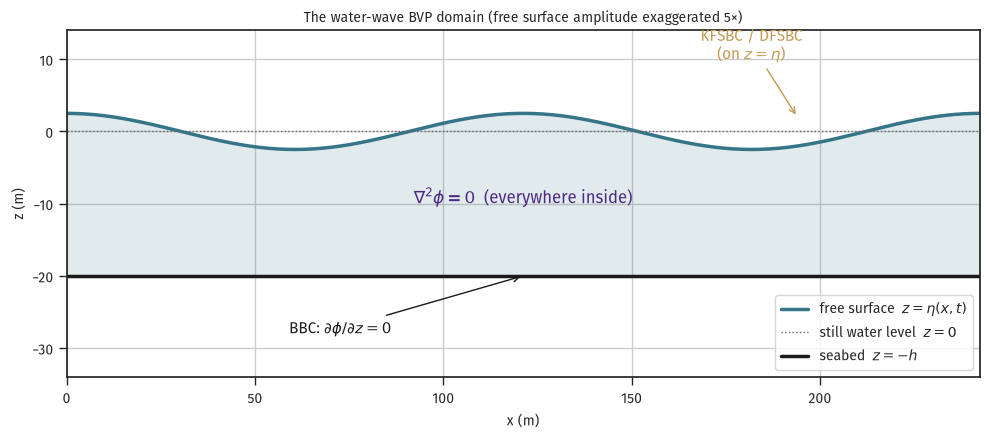

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))

xx = np.linspace(0, 2*2*np.pi/k, 400)
eta_curve = 5*eta(xx, 0)   # 5x vertical exaggeration

ax.fill_between(xx, -h, eta_curve, color=fs.color_list[1], alpha=0.15)
ax.plot(xx, eta_curve, lw=2.5, color=fs.color_list[1], label=r'free surface  $z = \eta(x,t)$')
ax.axhline(0, ls=':', color='0.4', lw=1, label='still water level  $z = 0$')
ax.axhline(-h, color='k', lw=2.5, label=r'seabed  $z = -h$')

ax.annotate('KFSBC / DFSBC\n(on $z = \\eta$)', xy=(0.8*xx[-1], 4*H/2), xytext=(0.75*xx[-1], 10),
            ha='center', fontsize=11, color=fs.color_list[3],
            arrowprops=dict(arrowstyle='->', color=fs.color_list[3]))
ax.annotate(r'BBC: $\partial\phi/\partial z = 0$', xy=(0.5*xx[-1], -h), xytext=(0.3*xx[-1], -h-8),
            ha='center', fontsize=11, color='k',
            arrowprops=dict(arrowstyle='->', color='k'))
ax.text(0.5*xx[-1], -0.5*h, r'$\nabla^2\phi = 0$  (everywhere inside)',
        ha='center', fontsize=12, color=fs.color_list[0])

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.set_xlim(xx[0], xx[-1])
ax.set_ylim(-h-14, 14)
ax.set_title('The water-wave BVP domain (free surface amplitude exaggerated 5×)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 5. Exercises

1. Add a surface-tension term to the DFSBC: $P = -\sigma_s \kappa$ on $z = \eta$. Here $\sigma_s$ is surface tension ($\approx 0.073\,$N/m for clean water) and $\kappa$ is the surface curvature. For a wave of length $L$, surface tension matters when $\sigma_s k^2 / (\rho g) \gtrsim 1$. What wavelength does that correspond to? (Answer: about 1.7 cm, the capillary cutoff from Week 1.)

2. The $(ka)^2$ sweep above held $T$ and $h$ fixed and varied $H$. Hold $H$ and $T$ fixed instead and sweep $h$ from 2 m to 200 m. Does the residual still scale as $(ka)^2$? Plot it against $ka$ and against $kh$. Which of the two does the residual respond to?

3. Replace the flat bed with a gentle slope, $h(x) = h_0(1 - \varepsilon x/L)$ with $\varepsilon = 0.05$. Evaluate the bottom boundary condition $w + u\,\partial h/\partial x = 0$ using the flat-bottom Airy fields. How large is the residual relative to $|w|$, and how does it scale with $\varepsilon$? The mild-slope assumption of Week 8 neglects this error.

## Looking ahead

In Week 5 we linearize this BVP and solve it by separation of variables. We obtain the Airy solution we just wrote down and the dispersion relation $\omega^2 = gk\tanh kh$. The Week 5 notebook accompanies that derivation.